# Import modules

In [1]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.pipeline2.Helper import (
    create_preprocessing_pipeline,
    load_and_split_data,
    preprocess_training_data,
    scale_and_handle_outliers,
    preprocess_test_data,
    evaluate_model, 
    save_model_and_pipeline,
    predict_new_data,
)

# Preparation

In [2]:
# 1. Load and split data T
train_data, test_data = load_and_split_data()

# 2. Create pipeline
pipeline = create_preprocessing_pipeline()

# 3. Fit pipeline on train data only
X_train, y_train, missing_fill_strategy = preprocess_training_data(train_data, pipeline)

# 4. Scale based on training data
X_train_scaled, scaler, bounds, numeric_features = scale_and_handle_outliers(X_train)

# 5. Apply fitted pipeline and scaler to test data
X_test_scaled, y_test = preprocess_test_data(
    test_data,
    pipeline,
    scaler,
    bounds,
    numeric_features,
    missing_fill_strategy=missing_fill_strategy,
)

LOADING AND SPLITTING DATA


d:\Study\VPBank_Hackathon_25\src\pipeline2\Helper.py:82: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path)


Raw data loaded: (100000, 28)
After dropping personal info: (100000, 21)
Train data: (80000, 21)
Test data: (20000, 21)

PREPROCESSING TRAINING DATA
Training data after pipeline: (80000, 37)
Handling negative values...
Total negative values converted: 0
Handling missing values with intelligent strategy...
  Monthly_Inhand_Salary: 12032 missing -> median (3191104166666666.0000) (skewed: 2.60)
  Num_of_Delayed_Payment: 5595 missing -> median (14.0000) (skewed: 14.21)
  Changed_Credit_Limit: 1691 missing -> median (902.0000) (skewed: 10.44)
  Num_Credit_Inquiries: 1549 missing -> median (60.0000) (skewed: 9.69)
  Credit_History_Age: 7240 missing -> mean (18.4345) (normal dist)
  Amount_invested_monthly: 3605 missing -> median (8131127094677352.0000) (skewed: 1.77)
  Monthly_Balance: 950 missing -> median (6580492431588418.0000) (skewed: 106.26)
Converting object columns to numeric...
Training features: (80000, 36)
Training target distribution: {0: 14262, 1: 23199, 2: 42539}

SCALING AND O

c:\Users\PC\miniconda3\envs\vpbank\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


# XGBoost


TRAINING XGBOOST MODEL
Training XGBoost...
Training completed!

MODEL EVALUATION
Test Accuracy: 0.7915

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.72      0.74      3566
           1       0.79      0.79      0.79      5799
           2       0.80      0.82      0.81     10635

    accuracy                           0.79     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.79      0.79      0.79     20000



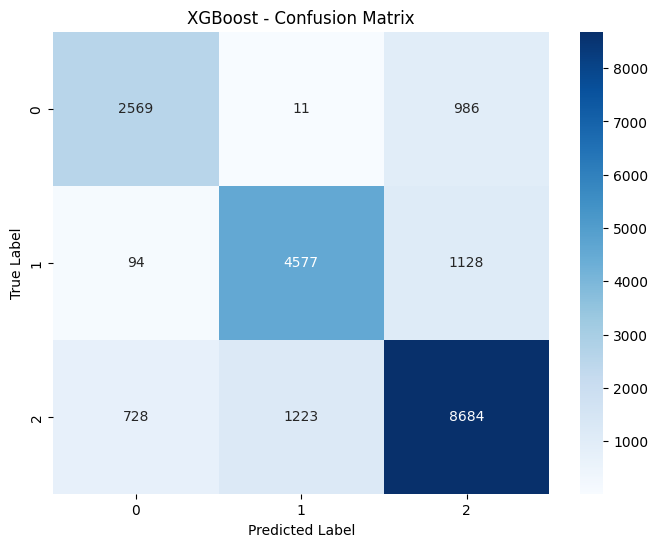


SAVING MODEL AND COMPONENTS
Preprocessing pipeline saved to: ..\models\xgboost_preprocessing_pipeline.pkl
XGBoost model saved to: ..\models\xgboost.pkl
Scaler saved to: ..\models\xgboost_scaler.pkl
Model info saved to: ..\models\xgboost_info.pkl


In [3]:
from src.pipeline2.XGBoost import train_xgboost_model

model = train_xgboost_model(X_train, y_train)

accuracy = evaluate_model(model, X_test_scaled, y_test)

model_path, pipeline_path, scaler_path, info_path = save_model_and_pipeline(
    model,
    pipeline,
    scaler,
    bounds,
    numeric_features,
    importance_df=None,
    accuracy=accuracy,
    missing_fill_strategy=missing_fill_strategy,
    model_name="xgboost",
)

# Random Forest


TRAINING RANDOM FOREST MODEL
Training Random Forest...
Training completed!

MODEL EVALUATION
Test Accuracy: 0.7136

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.82      0.64      3566
           1       0.71      0.80      0.75      5799
           2       0.86      0.63      0.73     10635

    accuracy                           0.71     20000
   macro avg       0.70      0.75      0.70     20000
weighted avg       0.76      0.71      0.72     20000



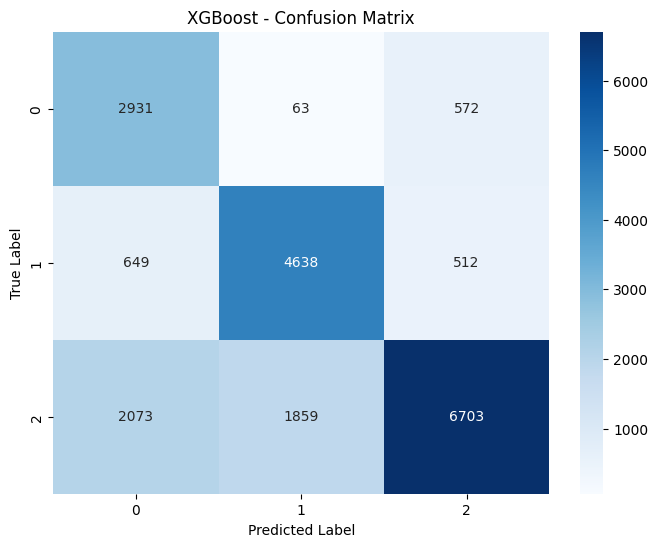


SAVING MODEL AND COMPONENTS
Preprocessing pipeline saved to: ..\models\randomforest_preprocessing_pipeline.pkl
XGBoost model saved to: ..\models\randomforest.pkl
Scaler saved to: ..\models\randomforest_scaler.pkl
Model info saved to: ..\models\randomforest_info.pkl


In [3]:
from src.pipeline2.RandomForest import train_randomforest_model

model = train_randomforest_model(X_train, y_train)

accuracy = evaluate_model(model, X_test_scaled, y_test)

model_path, pipeline_path, scaler_path, info_path = save_model_and_pipeline(
    model,
    pipeline,
    scaler,
    bounds,
    numeric_features,
    importance_df=None,
    accuracy=accuracy,
    missing_fill_strategy=missing_fill_strategy,
    model_name="randomforest",
)


# TabNet


TRAINING TABNET MODEL
Train split: (64000, 36)
Validation split: (16000, 36)
Training TabNet...


c:\Users\PC\miniconda3\envs\vpbank\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.99687 | val_accuracy: 0.49438 |  0:00:12s
epoch 1  | loss: 0.80007 | val_accuracy: 0.56931 |  0:00:25s
epoch 2  | loss: 0.78765 | val_accuracy: 0.62381 |  0:00:38s
epoch 3  | loss: 0.77097 | val_accuracy: 0.64425 |  0:00:57s
epoch 4  | loss: 0.76611 | val_accuracy: 0.6475  |  0:01:22s
Stop training because you reached max_epochs = 5 with best_epoch = 4 and best_val_accuracy = 0.6475


c:\Users\PC\miniconda3\envs\vpbank\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training completed!

MODEL EVALUATION
Error during prediction: 0
Model type: <class 'pytorch_tabnet.tab_model.TabNetClassifier'>
X_test type: <class 'pandas.core.frame.DataFrame'>, shape: (20000, 36)
Detected TabNet model - converting data format...
Test Accuracy: 0.6441

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.67      0.58      3566
           1       0.61      0.69      0.64      5799
           2       0.75      0.61      0.67     10635

    accuracy                           0.64     20000
   macro avg       0.62      0.66      0.63     20000
weighted avg       0.66      0.64      0.65     20000



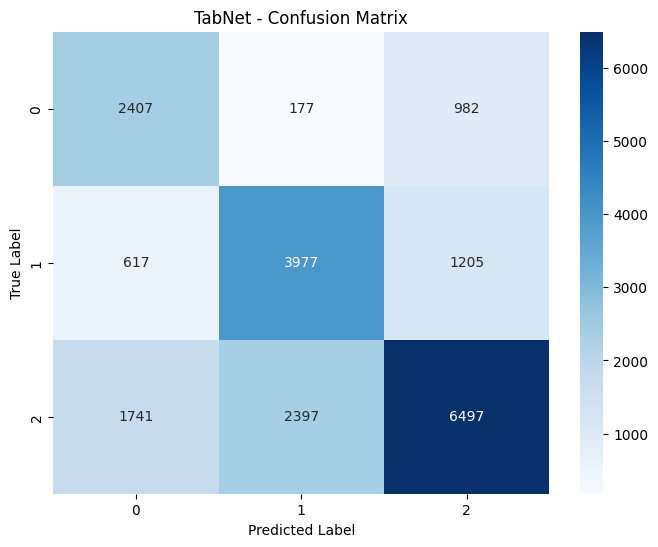


SAVING MODEL AND COMPONENTS
Preprocessing pipeline saved to: ..\models\tabnet_preprocessing_pipeline.pkl
XGBoost model saved to: ..\models\tabnet.pkl
Scaler saved to: ..\models\tabnet_scaler.pkl
Model info saved to: ..\models\tabnet_info.pkl


In [3]:
from src.pipeline2.TabNet import train_tabnet_model

model = train_tabnet_model(X_train, y_train)

accuracy = evaluate_model(model, X_test_scaled, y_test)

model_path, pipeline_path, scaler_path, info_path = save_model_and_pipeline(
    model,
    pipeline,
    scaler,
    bounds,
    numeric_features,
    importance_df=None,
    accuracy=accuracy,
    missing_fill_strategy=missing_fill_strategy,
    model_name="tabnet",
)